<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-36-lasso-regression-regularization?scriptVersionId=343923667" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, #1a0533 0%, #2d1b4e 50%, #3b1f6b 100%); padding: 48px 40px; border-radius: 16px; margin-bottom: 8px;">
  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="background: #c084fc; color: #1a0533; font-size: 11px; font-weight: 700; letter-spacing: 2px; padding: 4px 12px; border-radius: 20px; text-transform: uppercase;">ML Series · Episode 36</span>
  </div>
  <h1 style="color: #ffffff; font-size: 38px; font-weight: 800; margin: 0 0 12px 0; line-height: 1.2;">✂️ Lasso Regularization</h1>
  <p style="color: #d4b8f0; font-size: 17px; margin: 0 0 28px 0; max-width: 620px; line-height: 1.6;">The L1 penalty that doesn't just shrink coefficients — it drives them to exactly zero, performing automatic feature selection.</p>
  <div style="display: flex; gap: 24px; flex-wrap: wrap;">
    <div style="background: rgba(255,255,255,0.07); border: 1px solid rgba(255,255,255,0.15); border-radius: 10px; padding: 14px 20px;">
      <div style="color: #c084fc; font-size: 22px; font-weight: 700;">L1</div>
      <div style="color: #a78bca; font-size: 12px; margin-top: 2px;">Penalty Type</div>
    </div>
    <div style="background: rgba(255,255,255,0.07); border: 1px solid rgba(255,255,255,0.15); border-radius: 10px; padding: 14px 20px;">
      <div style="color: #c084fc; font-size: 22px; font-weight: 700;">Zeros Out</div>
      <div style="color: #a78bca; font-size: 12px; margin-top: 2px;">Irrelevant Features</div>
    </div>
    <div style="background: rgba(255,255,255,0.07); border: 1px solid rgba(255,255,255,0.15); border-radius: 10px; padding: 14px 20px;">
      <div style="color: #c084fc; font-size: 22px; font-weight: 700;">sklearn</div>
      <div style="color: #a78bca; font-size: 12px; margin-top: 2px;">Lasso · LassoCV</div>
    </div>
  </div>
</div>

<div style="background: #f5f0ff; border-left: 5px solid #c084fc; border-radius: 0 10px 10px 0; padding: 20px 24px; margin: 24px 0;">
  <h2 style="color: #1a0533; font-size: 15px; font-weight: 700; text-transform: uppercase; letter-spacing: 1.5px; margin: 0 0 10px 0;">📋 Table of Contents</h2>
  <ol style="margin: 0; padding-left: 20px; color: #7c3aed; line-height: 2; font-size: 14px;">
    <li><a href='#concept' style='color: #7c3aed; text-decoration: none;'>Lasso vs Ridge — The Key Difference</a></li>
    <li><a href='#imports' style='color: #7c3aed; text-decoration: none;'>Imports &amp; Setup</a></li>
    <li><a href='#highdim' style='color: #7c3aed; text-decoration: none;'>High-Dimensional Data — Where Lasso Shines</a></li>
    <li><a href='#poly' style='color: #7c3aed; text-decoration: none;'>Lasso on Polynomial Features — Alpha Effect</a></li>
    <li><a href='#coef' style='color: #7c3aed; text-decoration: none;'>How Coefficients Are Affected by Alpha</a></li>
    <li><a href='#path' style='color: #7c3aed; text-decoration: none;'>Regularization Path — All Features Together</a></li>
    <li><a href='#biasvar' style='color: #7c3aed; text-decoration: none;'>Bias–Variance Tradeoff with Lasso</a></li>
    <li><a href='#loss' style='color: #7c3aed; text-decoration: none;'>Effect of Alpha on the Loss Function</a></li>
    <li><a href='#sparsity' style='color: #7c3aed; text-decoration: none;'>Why Does Lasso Create Sparsity?</a></li>
  </ol>
</div>

<a id='concept'></a>
<div style="border-bottom: 2px solid #c084fc; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #c084fc; color: #1a0533; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 1</span>
  <h2 style="color: #1a0533; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Lasso vs Ridge — The Key Difference</h2>
</div>

Both Ridge and Lasso add a penalty to the OLS cost function to combat overfitting. The difference is **which norm** they penalise:

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin: 20px 0;">
  <div style="background: #1a0533; border-radius: 10px; padding: 20px 24px;">
    <div style="color: #a78bca; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 10px;">Ridge — L2 Penalty</div>
    <div style="color: #e9d5ff; font-size: 18px; font-weight: 700; font-family: Georgia, serif;">J = MSE + λ · Σθᵢ²</div>
    <div style="color: #a78bca; font-size: 12px; margin-top: 10px; line-height: 1.6;">Penalises the <strong style='color:#c084fc;'>square</strong> of coefficients. Shrinks all toward zero — but never exactly to zero.</div>
  </div>
  <div style="background: #1a0533; border: 2px solid #c084fc; border-radius: 10px; padding: 20px 24px;">
    <div style="color: #c084fc; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 10px;">Lasso — L1 Penalty ✦ This Episode</div>
    <div style="color: #e9d5ff; font-size: 18px; font-weight: 700; font-family: Georgia, serif;">J = MSE + λ · Σ|θᵢ|</div>
    <div style="color: #a78bca; font-size: 12px; margin-top: 10px; line-height: 1.6;">Penalises the <strong style='color:#c084fc;'>absolute value</strong> of coefficients. Can drive them to <strong style='color:#c084fc;'>exactly zero</strong> — eliminating features entirely.</div>
  </div>
</div>

<div style="display: flex; gap: 14px; margin: 16px 0; flex-wrap: wrap;">
  <div style="flex: 1; min-width: 200px; background: #f5f0ff; border: 1px solid #ddd6fe; border-radius: 8px; padding: 14px 18px;">
    <div style="color: #6d28d9; font-weight: 700; font-size: 13px; margin-bottom: 4px;">✂️ Built-in Feature Selection</div>
    <div style="color: #444; font-size: 13px;">Lasso zeros out unimportant features automatically — no need for manual selection or separate elimination steps.</div>
  </div>
  <div style="flex: 1; min-width: 200px; background: #f5f0ff; border: 1px solid #ddd6fe; border-radius: 8px; padding: 14px 18px;">
    <div style="color: #6d28d9; font-weight: 700; font-size: 13px; margin-bottom: 4px;">📦 Sparse Models</div>
    <div style="color: #444; font-size: 13px;">The resulting model uses only a subset of features — easier to interpret, faster to predict, and more robust to noise.</div>
  </div>
  <div style="flex: 1; min-width: 200px; background: #fff8f0; border: 1px solid #fed7aa; border-radius: 8px; padding: 14px 18px;">
    <div style="color: #c2410c; font-weight: 700; font-size: 13px; margin-bottom: 4px;">⚠️ When Ridge is Better</div>
    <div style="color: #444; font-size: 13px;">If most features are genuinely informative and correlated, Ridge is preferred — Lasso may arbitrarily discard some.</div>
  </div>
</div>

<a id='imports'></a>
<div style="border-bottom: 2px solid #c084fc; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #c084fc; color: #1a0533; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 2</span>
  <h2 style="color: #1a0533; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Imports &amp; Setup</h2>
</div>

We import everything upfront. Notable addition compared to previous episodes: `mlxtend.evaluate.bias_variance_decomp` — a utility that runs bootstrap resampling to decompose total prediction error into its bias and variance components.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

<a id='highdim'></a>
<div style="border-bottom: 2px solid #c084fc; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #c084fc; color: #1a0533; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 3</span>
  <h2 style="color: #1a0533; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">High-Dimensional Data — Where Lasso Shines</h2>
</div>

This is Lasso's signature use case. We create a dataset with **5000 features** but only **50 are actually informative** — the other 4950 are pure noise. Ordinary Linear Regression gets overwhelmed by the noise and performs poorly. Lasso zeros out all irrelevant features and recovers the true signal.

<div style="background: #1a0533; border-radius: 10px; padding: 18px 24px; margin: 16px 0;">
  <div style="color: #a78bca; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 10px;">Dataset Setup</div>
  <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 12px; font-size: 13px;">
    <div style="text-align: center;">
      <div style="color: #c084fc; font-size: 24px; font-weight: 800;">1000</div>
      <div style="color: #a78bca;">samples</div>
    </div>
    <div style="text-align: center;">
      <div style="color: #c084fc; font-size: 24px; font-weight: 800;">5000</div>
      <div style="color: #a78bca;">total features</div>
    </div>
    <div style="text-align: center;">
      <div style="color: #c084fc; font-size: 24px; font-weight: 800;">50</div>
      <div style="color: #a78bca;">informative features</div>
    </div>
  </div>
</div>

In [2]:
# 5000 features, only 50 informative — a classic needle-in-a-haystack problem
X, y = make_regression(
    n_samples=1000,
    n_features=5000,
    n_informative=50,
    n_targets=1,
    noise=20,
    random_state=13
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")

Training set : (800, 5000)
Test set     : (200, 5000)


In [3]:
# Baseline: ordinary linear regression on 5000 features
lr = LinearRegression()
lr.fit(X_train, y_train)

print(f"Linear R²: {r2_score(y_test, lr.predict(X_test)):.3f}")
print(f"Non-zero coefficients: {np.sum(lr.coef_ != 0)} / {len(lr.coef_)}")

Linear R²: 0.183
Non-zero coefficients: 5000 / 5000


<div style="background: #fff8f0; border-left: 4px solid #f97316; border-radius: 0 8px 8px 0; padding: 13px 18px; margin: 12px 0; font-size: 14px; color: #333;">
  <strong style="color: #c2410c;">⚠️ Linear Regression R² ≈ 0.18</strong> — it uses all 5000 coefficients including 4950 noise features, fitting random fluctuations and generalising poorly. This is a textbook case of the <strong>curse of dimensionality</strong>.
</div>

In [4]:
# Lasso at multiple alpha values — watch R² stay near-perfect
print(f"{'Alpha':<10} {'R²':>8} {'Non-zero coefs':>16}")
print("-" * 36)

for alpha in [0.1, 0.5, 1, 5, 10, 15, 30]:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    r2  = r2_score(y_test, lasso.predict(X_test))
    nz  = np.sum(lasso.coef_ != 0)
    print(f"{alpha:<10} {r2:>8.3f} {nz:>16}")

Alpha            R²   Non-zero coefs
------------------------------------
0.1           0.996              822
0.5           0.996              552
1             0.997              350
5             0.990               51
10            0.971               46
15            0.940               44
30            0.795               39


<div style="background: #f0fff4; border-left: 4px solid #c084fc; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 12px 0; font-size: 14px; color: #333;">
  <strong style="color: #6d28d9;">✅ Lasso R² ≈ 0.997</strong> — an enormous leap from 0.18. Lasso automatically zeroed out ~4950 noise coefficients and kept only the ~50 informative ones. The model is both more accurate <em>and</em> far simpler. This is the power of L1 regularization as a feature selector.
</div>

In [5]:
# Best model: alpha=1.0
lasso = Lasso(alpha=1.0).fit(X_train, y_train)
print(f"Lasso R²  : {r2_score(y_test, lasso.predict(X_test)):.3f}")
print(f"Non-zero coefs kept : {np.sum(lasso.coef_ != 0)} out of {len(lasso.coef_)}")

Lasso R²  : 0.997
Non-zero coefs kept : 350 out of 5000


<a id='poly'></a>
<div style="border-bottom: 2px solid #c084fc; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #c084fc; color: #1a0533; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 4</span>
  <h2 style="color: #1a0533; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Lasso on Polynomial Features — Alpha Effect</h2>
</div>

Just like Ridge in Episode 35, we fit a **degree-16 polynomial pipeline** on a noisy quadratic dataset. With Lasso, the penalty is L1 — so increasing alpha doesn't just shrink the curve, it eliminates polynomial terms entirely. The model becomes sparser with each alpha step.

<div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 12px; margin: 16px 0;">
  <div style="background: #fff0f0; border: 1px solid #fecaca; border-radius: 8px; padding: 14px; text-align: center;">
    <div style="font-size: 20px; margin-bottom: 6px;">🔴</div>
    <div style="color: #991b1b; font-weight: 700; font-size: 13px;">alpha = 0 (OLS)</div>
    <div style="color: #555; font-size: 12px; margin-top: 4px;">No penalty — degree-16 OLS. Wildly overfits every noise spike.</div>
  </div>
  <div style="background: #f0fff4; border: 1px solid #bbf7d0; border-radius: 8px; padding: 14px; text-align: center;">
    <div style="font-size: 20px; margin-bottom: 6px;">🟢</div>
    <div style="color: #15803d; font-weight: 700; font-size: 13px;">alpha = 0.1</div>
    <div style="color: #555; font-size: 12px; margin-top: 4px;">Light L1 — many terms eliminated, smooth curve, good fit.</div>
  </div>
  <div style="background: #eff6ff; border: 1px solid #bfdbfe; border-radius: 8px; padding: 14px; text-align: center;">
    <div style="font-size: 20px; margin-bottom: 6px;">🔵</div>
    <div style="color: #1d4ed8; font-weight: 700; font-size: 13px;">alpha = 1</div>
    <div style="color: #555; font-size: 12px; margin-top: 4px;">Strong L1 — most terms zeroed out. Very smooth, may underfit slightly.</div>
  </div>
</div>

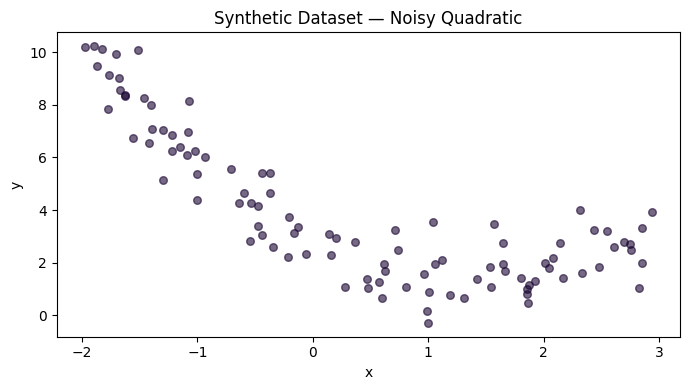

In [6]:
np.random.seed(42)
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.figure(figsize=(7, 4))
plt.scatter(x1, x2, color='#1a0533', alpha=0.6, s=30)
plt.title("Synthetic Dataset — Noisy Quadratic")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

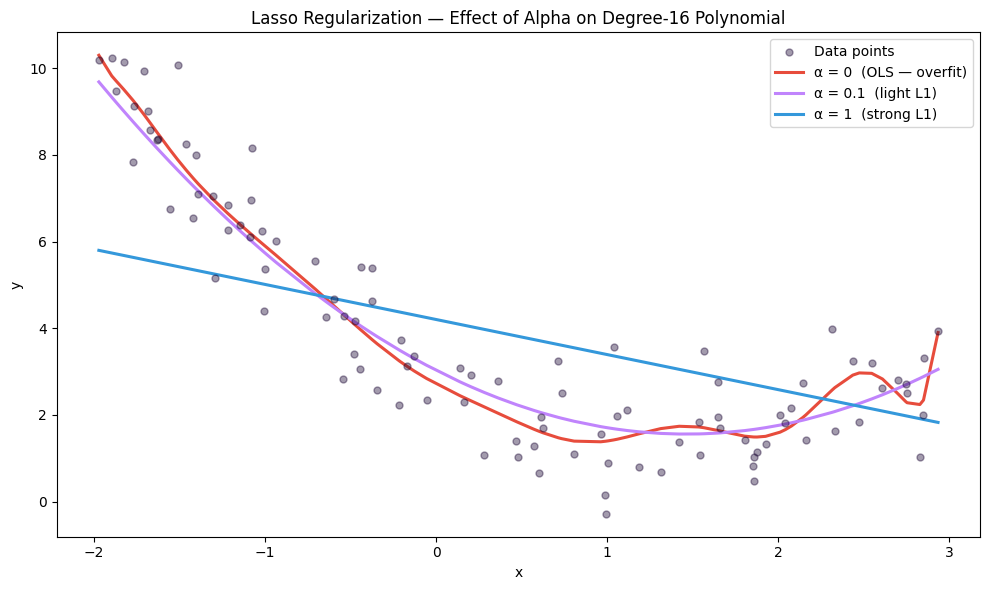

In [7]:
def get_preds_lasso(x1, x2, alpha):
    """Fit a degree-16 Lasso pipeline (or OLS if alpha=0) and return predictions."""
    if alpha == 0:
        model = Pipeline([
            ('poly_feats', PolynomialFeatures(degree=16)),
            ('scaler', StandardScaler()),
            ('linear', LinearRegression())
        ])
    else:
        model = Pipeline([
            ('poly_feats', PolynomialFeatures(degree=16)),
            ('scaler', StandardScaler()),
            ('lasso', Lasso(alpha=alpha, max_iter=10000))
        ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 0.1, 1]
colors = ['#e74c3c', '#c084fc', '#3498db']
labels = ['α = 0  (OLS — overfit)', 'α = 0.1  (light L1)', 'α = 1  (strong L1)']

plt.figure(figsize=(10, 6))
sort_idx = np.argsort(x1[:, 0])
plt.scatter(x1, x2, color='#1a0533', alpha=0.4, s=25, zorder=5, label='Data points')

for alpha, c, lbl in zip(alphas, colors, labels):
    preds = get_preds_lasso(x1, x2, alpha)
    plt.plot(x1[sort_idx, 0], preds[sort_idx], color=c, linewidth=2.2, label=lbl)

plt.legend(fontsize=10)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Lasso Regularization — Effect of Alpha on Degree-16 Polynomial")
plt.tight_layout()
plt.show()

<a id='coef'></a>
<div style="border-bottom: 2px solid #c084fc; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #c084fc; color: #1a0533; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 5</span>
  <h2 style="color: #1a0533; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">How Coefficients Are Affected by Alpha</h2>
</div>

Here we use the **Diabetes dataset** (10 medical features) and track how each coefficient changes as alpha grows. Unlike Ridge — which shrinks all gradually — Lasso performs **hard thresholding**: weak coefficients snap to zero while strong ones survive longer. This 2×2 grid makes the progression crystal clear.

<div style="background: #f5f0ff; border: 1px solid #ddd6fe; border-radius: 8px; padding: 14px 18px; margin: 14px 0; font-size: 13px;">
  <strong style="color: #6d28d9;">🔍 What to look for:</strong> At alpha≈0 all coefficients are nearly identical to OLS. As alpha increases, the weakest predictors (low correlation with target) hit zero first — <code>age</code>, <code>sex</code>, <code>s4</code>. By alpha=10, only the intercept survives.
</div>

In [8]:
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['TARGET'] = data.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

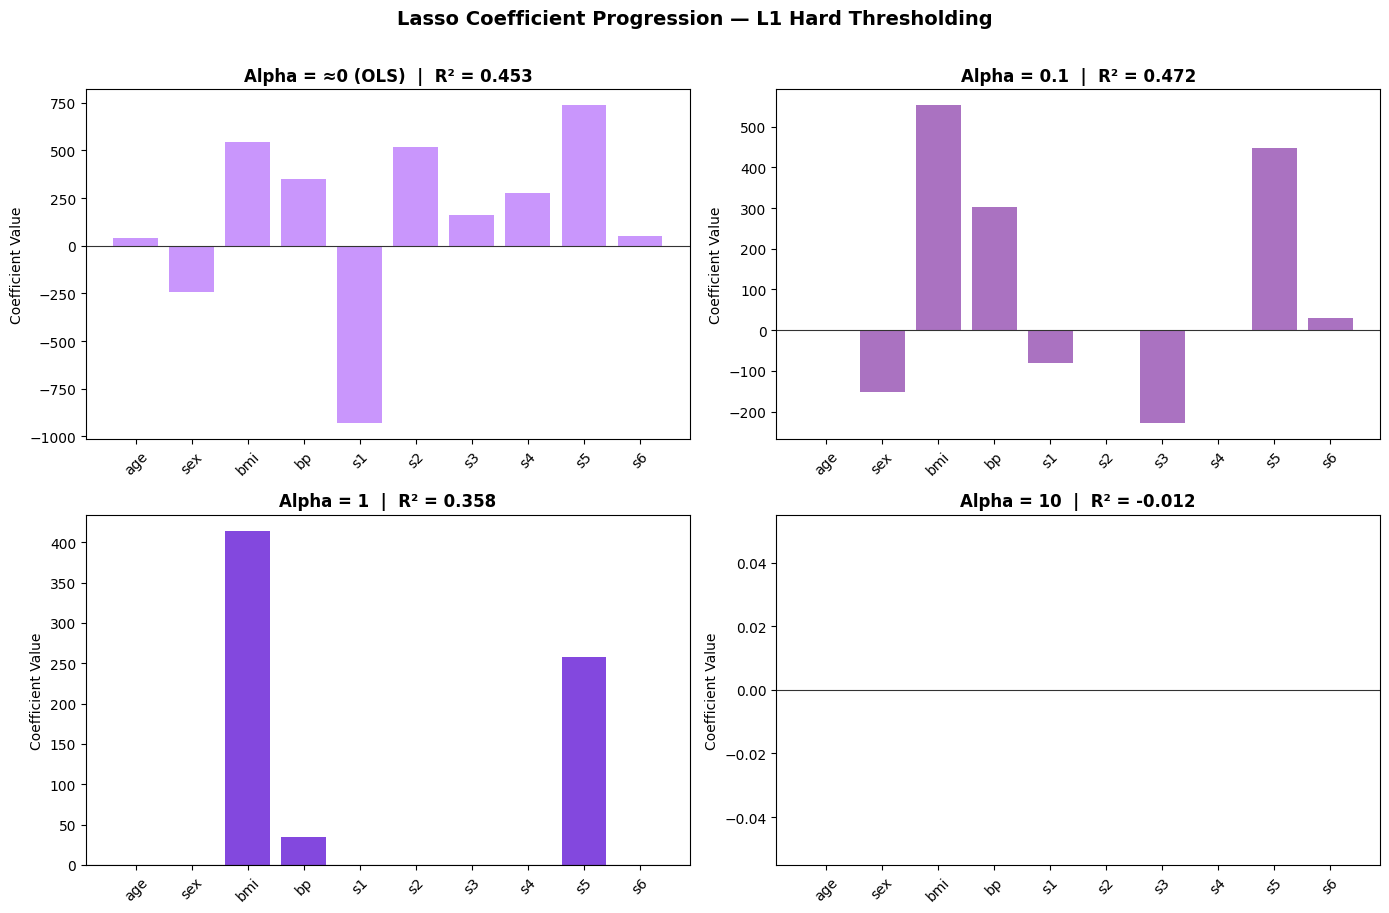

In [10]:
coefs    = []
r2_scores = []

for alpha in [0.0000001, 0.1, 1, 10]:
    reg = Lasso(alpha=alpha)
    reg.fit(X_train, y_train)
    coefs.append(reg.coef_.tolist())
    r2_scores.append(r2_score(y_test, reg.predict(X_test)))

alpha_labels = ['≈0 (OLS)', '0.1', '1', '10']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
colors_bar = ['#c084fc', '#9b59b6', '#6d28d9', '#4c1d95']

for idx, ax in enumerate(axes.ravel()):
    bars = ax.bar(data.feature_names, coefs[idx], color=colors_bar[idx], alpha=0.85)
    ax.set_title(f'Alpha = {alpha_labels[idx]}  |  R² = {round(r2_scores[idx], 3)}',
                 fontsize=12, fontweight='bold')
    ax.axhline(0, color='#333', linewidth=0.8)
    ax.set_ylabel('Coefficient Value')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Lasso Coefficient Progression — L1 Hard Thresholding',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

<div style="background: #f5f0ff; border-left: 4px solid #c084fc; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 12px 0; font-size: 14px; color: #333;">
  <strong style="color: #6d28d9;">✅ L1 Hard Thresholding in action:</strong> At alpha=1, features like <code>age</code>, <code>sex</code>, <code>s1</code>, <code>s2</code>, <code>s4</code>, and <code>s6</code> are zeroed out completely — only <code>bmi</code>, <code>bp</code>, and <code>s5</code> remain. By alpha=10, every coefficient is zero. Ridge would never do this — it can only approach zero asymptotically.
</div>

<a id='path'></a>
<div style="border-bottom: 2px solid #c084fc; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #c084fc; color: #1a0533; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 6</span>
  <h2 style="color: #1a0533; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Regularization Path — All Features Together</h2>
</div>

A **regularization path** plots how every feature's coefficient changes across a range of alpha values on the same axes. This reveals the **elimination order** — which features Lasso discards first (weakest predictors) and which survive longest (strongest predictors).

The black horizontal line at y=0 is the zero boundary. When a feature's line crosses it and stays there, that feature has been permanently eliminated from the model.

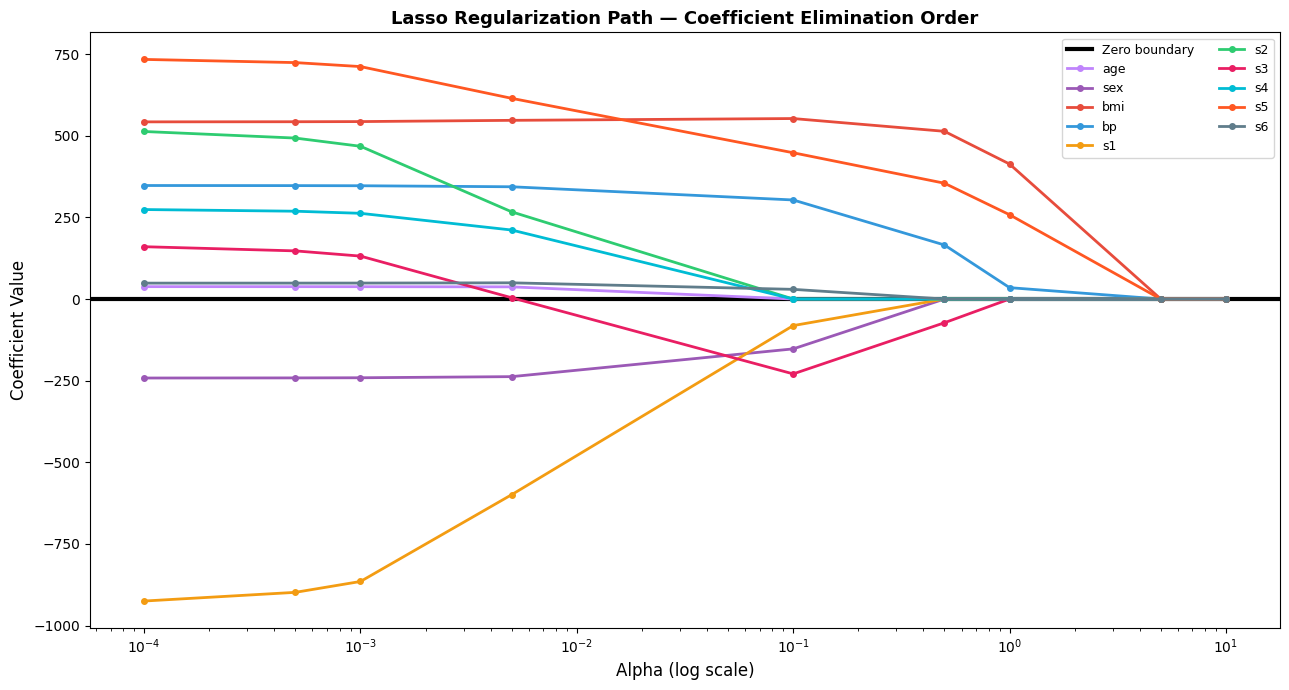

In [11]:
alphas_path = [0.0001, 0.0005, 0.001, 0.005, 0.1, 0.5, 1, 5, 10]
coefs_path  = []

for alpha in alphas_path:
    reg = Lasso(alpha=alpha)
    reg.fit(X_train, y_train)
    coefs_path.append(reg.coef_.tolist())

coef_matrix = np.array(coefs_path).T   # shape: (n_features, n_alphas)

feature_colors = [
    '#c084fc', '#9b59b6', '#e74c3c', '#3498db',
    '#f39c12', '#2ecc71', '#e91e63', '#00bcd4', '#ff5722', '#607d8b'
]

plt.figure(figsize=(13, 7))
plt.axhline(0, color='black', linewidth=3, zorder=2, label='Zero boundary')

for i in range(coef_matrix.shape[0]):
    plt.plot(alphas_path, coef_matrix[i], color=feature_colors[i],
             linewidth=2, label=data.feature_names[i], marker='o', markersize=4)

plt.xscale('log')
plt.xlabel("Alpha (log scale)", fontsize=12)
plt.ylabel("Coefficient Value", fontsize=12)
plt.title("Lasso Regularization Path — Coefficient Elimination Order", fontsize=13, fontweight='bold')
plt.legend(loc='upper right', fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

<div style="background: #f5f0ff; border-left: 4px solid #c084fc; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 12px 0; font-size: 14px; color: #333;">
  <strong style="color: #6d28d9;">✅ Reading the path:</strong> Features with strong predictive power (like <code>bmi</code> and <code>s5</code>) survive until high alpha values. Weak features (<code>age</code>, <code>sex</code>, <code>s4</code>) cross zero early and stay eliminated. This ordering is unique to Lasso — Ridge never eliminates, only compresses.
</div>

<div style="background: #fafafa; border: 1px solid #ddd; border-radius: 8px; padding: 14px 18px; margin: 14px 0; font-size: 13px; color: #555;">
  <strong style="color: #333;">📌 Practical use of the regularization path:</strong> In production, tools like <code>LassoCV</code> or <code>sklearn.linear_model.lasso_path()</code> compute this more efficiently using coordinate descent across all alphas simultaneously, then pick the optimal alpha via cross-validation.
</div>

<a id='biasvar'></a>
<div style="border-bottom: 2px solid #c084fc; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #c084fc; color: #1a0533; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 7</span>
  <h2 style="color: #1a0533; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Bias–Variance Tradeoff with Lasso</h2>
</div>

The **bias-variance tradeoff** is the fundamental tension in supervised learning: a model that's too simple has high bias (underfits), while one that's too complex has high variance (overfits). Regularization alpha controls this tradeoff directly.

<div style="background: #1a0533; border-radius: 10px; padding: 18px 24px; margin: 16px 0;">
  <div style="color: #a78bca; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 10px;">Total Error Decomposition</div>
  <div style="color: #e9d5ff; font-size: 16px; font-weight: 700; font-family: Georgia, serif; text-align: center;">
    Expected Loss = Bias² + Variance + Irreducible Noise
  </div>
  <div style="color: #a78bca; font-size: 12px; margin-top: 10px; text-align: center; line-height: 1.7;">
    Low alpha → Low Bias, High Variance &nbsp;|&nbsp; High alpha → High Bias, Low Variance
  </div>
</div>

We use `mlxtend.bias_variance_decomp` which runs **50 bootstrap rounds** — training on random subsets and averaging the decomposition across all rounds. This gives a stable, empirical estimate of how bias and variance shift with alpha.

In [12]:
# Prepare a synthetic 1D polynomial dataset for the bias-variance demo
np.random.seed(42)
m = 100
X_bv = 5 * np.random.rand(m, 1) - 2
y_bv = 0.7 * X_bv ** 2 - 2 * X_bv + 3 + np.random.randn(m, 1)

X_train_bv, X_test_bv, y_train_bv, y_test_bv = train_test_split(
    X_bv.reshape(100, 1), y_bv.reshape(100), test_size=0.2, random_state=2
)

# Expand to degree-10 polynomial features
poly = PolynomialFeatures(degree=10)
X_train_poly = poly.fit_transform(X_train_bv)
X_test_poly  = poly.transform(X_test_bv)

X_tr = np.asarray(X_train_poly)
y_tr = np.asarray(y_train_bv)
X_te = np.asarray(X_test_poly)
y_te = np.asarray(y_test_bv)

print(f"Polynomial feature shape: {X_tr.shape}")

Polynomial feature shape: (80, 11)


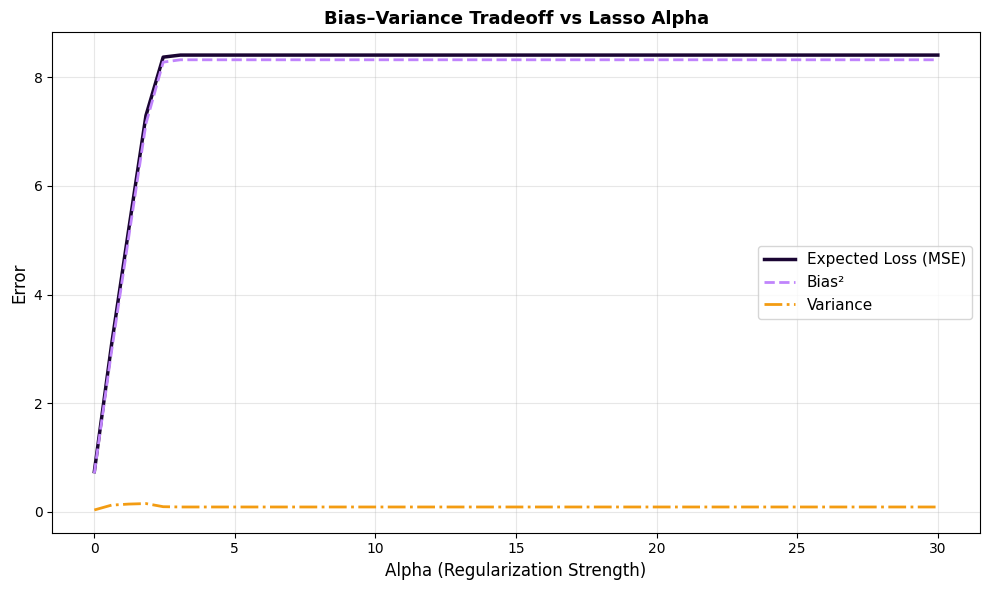

In [13]:
from mlxtend.evaluate import bias_variance_decomp

alphas_bv = np.linspace(0.01, 30, 50)
loss_list, bias_list, var_list = [], [], []

for alpha in alphas_bv:
    reg = make_pipeline(
        StandardScaler(),
        Lasso(alpha=alpha, max_iter=10000, tol=1e-3)
    )
    avg_loss, avg_bias, avg_var = bias_variance_decomp(
        reg, X_tr, y_tr, X_te, y_te,
        loss='mse', num_rounds=50, random_seed=123
    )
    loss_list.append(avg_loss)
    bias_list.append(avg_bias)
    var_list.append(avg_var)

plt.figure(figsize=(10, 6))
plt.plot(alphas_bv, loss_list, label='Expected Loss (MSE)', color='#1a0533', linewidth=2.5)
plt.plot(alphas_bv, bias_list, label='Bias²',               color='#c084fc', linewidth=2, linestyle='--')
plt.plot(alphas_bv, var_list,  label='Variance',             color='#f39c12', linewidth=2, linestyle='-.')
plt.xlabel('Alpha (Regularization Strength)', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Bias–Variance Tradeoff vs Lasso Alpha', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div style="background: #f5f0ff; border-left: 4px solid #c084fc; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 12px 0; font-size: 14px; color: #333;">
  <strong style="color: #6d28d9;">✅ Reading the curve:</strong> At low alpha, variance dominates (overfit). As alpha grows, variance drops sharply while bias rises slowly — the sweet spot is where total loss is minimised. Beyond that point, bias takes over and the model underfits. Use <strong>LassoCV</strong> to find this automatically.
</div>

<a id='loss'></a>
<div style="border-bottom: 2px solid #c084fc; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #c084fc; color: #1a0533; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 8</span>
  <h2 style="color: #1a0533; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Effect of Alpha on the Loss Function</h2>
</div>

Finally, we directly **visualise the Lasso loss surface** as a function of the slope parameter `m`. At alpha=0 the loss is a pure quadratic bowl (OLS). As alpha increases, the L1 penalty tilts and reshapes the bowl — shifting the minimum leftward toward zero. At high alpha, the penalty dominates so strongly that the minimum snaps to m=0.

<div style="background: #1a0533; border-radius: 10px; padding: 18px 24px; margin: 16px 0;">
  <div style="color: #a78bca; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 10px;">Lasso Loss Function</div>
  <div style="color: #e9d5ff; font-size: 18px; font-weight: 700; font-family: Georgia, serif; text-align: center;">
    L(m) = Σ(yᵢ − m·xᵢ + b)² + α · |m|
  </div>
  <div style="color: #a78bca; font-size: 12px; margin-top: 8px; text-align: center;">
    The <strong style='color:#c084fc;'>absolute value</strong> term creates a V-shaped addition — unlike the smooth parabolic addition in Ridge.
    This is why Lasso can produce exact zeros while Ridge cannot.
  </div>
</div>

In [14]:
# Fit a simple 1D linear model — we'll visualise the loss surface w.r.t its slope
X_loss, y_loss = make_regression(
    n_samples=100, n_features=1, n_informative=1,
    n_targets=1, noise=20, random_state=13
)

reg_base = LinearRegression()
reg_base.fit(X_loss, y_loss)
print(f"OLS coefficient : {reg_base.coef_[0]:.4f}")
print(f"OLS intercept   : {reg_base.intercept_:.4f}")

OLS coefficient : 27.8281
OLS intercept   : -2.2947


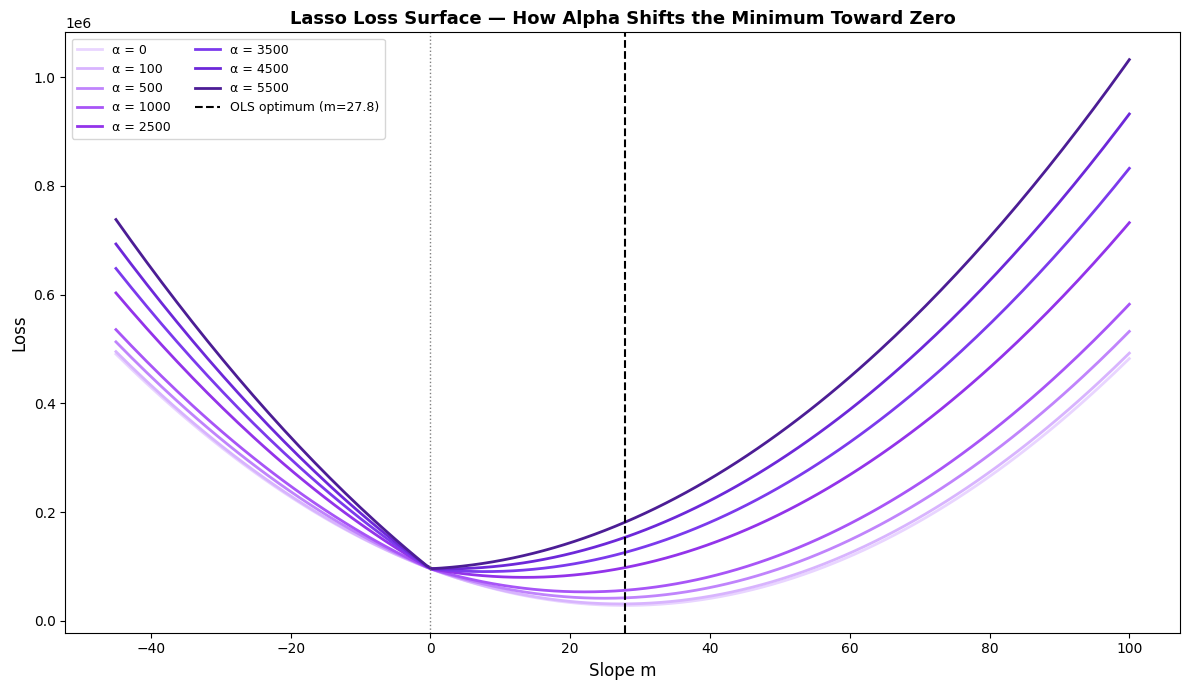

In [15]:
def cal_loss(m, alpha):
    """Lasso loss = MSE component + L1 penalty on slope m."""
    return np.sum((y_loss - m * X_loss.ravel() + 2.29) ** 2) + alpha * abs(m)

m_range = np.linspace(-45, 100, 200)
alpha_values = [0, 100, 500, 1000, 2500, 3500, 4500, 5500]

# Use a purple gradient palette
palette = [
    '#e9d5ff', '#d8b4fe', '#c084fc', '#a855f7',
    '#9333ea', '#7c3aed', '#6d28d9', '#4c1d95'
]

plt.figure(figsize=(12, 7))

for alpha, color in zip(alpha_values, palette):
    loss_vals = [cal_loss(mi, alpha) for mi in m_range]
    plt.plot(m_range, loss_vals, color=color, linewidth=2,
             label=f'α = {alpha}')

plt.axvline(x=reg_base.coef_[0], color='black', linewidth=1.5,
            linestyle='--', label=f'OLS optimum (m={reg_base.coef_[0]:.1f})')
plt.axvline(x=0, color='gray', linewidth=1, linestyle=':')
plt.legend(fontsize=9, ncol=2)
plt.xlabel('Slope m', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Lasso Loss Surface — How Alpha Shifts the Minimum Toward Zero', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background: #f5f0ff; border-left: 4px solid #c084fc; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 12px 0; font-size: 14px; color: #333;">
  <strong style="color: #6d28d9;">✅ The geometry of sparsity:</strong> At alpha=0 the minimum sits at the OLS solution (~27.8). As alpha grows, the V-shaped L1 penalty drags the minimum leftward. At very high alpha, the minimum reaches m=0 — the coefficient is fully eliminated. This is the geometric reason L1 produces sparse models while L2 cannot.
</div>

<a id='sparsity'></a>
<div style="border-bottom: 2px solid #c084fc; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #c084fc; color: #1a0533; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 9</span>
  <h2 style="color: #1a0533; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Why Does Lasso Create Sparsity?</h2>
</div>

We've *seen* Lasso zero out coefficients — but **why** does it do this mathematically, when Ridge (with nearly the same formula) never can? The answer lies in the **geometry of the constraint regions** and the **shape of the penalty function**.

This section builds intuition from three angles: algebraic, geometric, and visual.

### 9.1 — The Algebra: Absolute Value vs Square

Both Ridge and Lasso add a penalty to the OLS loss. The only difference is the norm used:

<div style="background: #1a0533; border-radius: 12px; padding: 24px 32px; margin: 20px 0;">
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 24px;">
    <div style="border-right: 1px solid rgba(192,132,252,0.3); padding-right: 24px;">
      <div style="color: #a78bca; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 12px;">Ridge — L2</div>
      <div style="color: #e9d5ff; font-size: 17px; font-family: Georgia, serif; margin-bottom: 10px;">J = MSE + λ · θ²</div>
      <div style="color: #a78bca; font-size: 13px; line-height: 1.7;">
        Derivative: <span style="color: #c084fc; font-weight: 600;">dJ/dθ = 2λθ</span><br/>
        At θ=0 → derivative = <strong style="color:#fff;">0</strong><br/>
        The gradient vanishes smoothly at zero — the penalty <em>pulls</em> toward zero but the force disappears exactly there. Coefficients approach but never reach zero.
      </div>
    </div>
    <div>
      <div style="color: #c084fc; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 12px;">Lasso — L1 ✦</div>
      <div style="color: #e9d5ff; font-size: 17px; font-family: Georgia, serif; margin-bottom: 10px;">J = MSE + λ · |θ|</div>
      <div style="color: #a78bca; font-size: 13px; line-height: 1.7;">
        Derivative: <span style="color: #c084fc; font-weight: 600;">dJ/dθ = λ · sign(θ)</span><br/>
        At θ≠0 → derivative = <strong style="color:#fff;">±λ</strong> (constant!)<br/>
        The penalty applies a <em>constant</em> force regardless of how small θ gets. It keeps pushing until the coefficient hits exactly zero — then stops.
      </div>
    </div>
  </div>
</div>

<div style="background: #f5f0ff; border-left: 4px solid #c084fc; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 12px 0; font-size: 14px; color: #333;">
  <strong style="color: #6d28d9;">💡 The Core Insight:</strong> Ridge's gradient is proportional to θ — it slows down as the coefficient shrinks. Lasso's gradient is <strong>constant</strong> (±λ) — it pushes with the same force no matter how small θ is, driving it all the way to zero. This is the algebraic reason L1 produces exact zeros while L2 cannot.
</div>

### 9.2 — The Geometry: Diamond vs Circle

Another way to understand sparsity is through **constrained optimisation**. Lasso can be rewritten as:

<div style="background: #1a0533; border-radius: 10px; padding: 18px 28px; margin: 16px 0; text-align: center;">
  <div style="color: #a78bca; font-size: 12px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 10px;">Equivalent Constrained Form</div>
  <div style="color: #e9d5ff; font-size: 17px; font-family: Georgia, serif;">
    minimise MSE(θ) &nbsp;&nbsp; subject to &nbsp;&nbsp; Σ|θᵢ| ≤ t
  </div>
  <div style="color: #a78bca; font-size: 12px; margin-top: 10px;">where t is determined by λ — larger λ → smaller t → tighter constraint</div>
</div>

The constraint region for Lasso (`Σ|θ| ≤ t`) is a **diamond** (L1 ball) in parameter space. For Ridge (`Σθ² ≤ t`) it is a **circle** (L2 ball).

The OLS solution sits somewhere in the unconstrained space. The optimal regularised solution is where the **MSE contour ellipses first touch the constraint region**:

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin: 16px 0;">
  <div style="background: #f5f0ff; border: 1px solid #ddd6fe; border-radius: 10px; padding: 16px 18px; text-align: center;">
    <div style="font-size: 28px; margin-bottom: 8px;">🔷</div>
    <div style="color: #6d28d9; font-weight: 700; font-size: 14px; margin-bottom: 6px;">Lasso — Diamond (L1 Ball)</div>
    <div style="color: #444; font-size: 13px; line-height: 1.6;">The diamond has sharp <strong>corners on the axes</strong>. The MSE ellipses are very likely to first touch the constraint at a corner — and corners correspond to θ = 0 for one or more features. This is why Lasso produces zeros.</div>
  </div>
  <div style="background: #f0fff4; border: 1px solid #bbf7d0; border-radius: 10px; padding: 16px 18px; text-align: center;">
    <div style="font-size: 28px; margin-bottom: 8px;">⭕</div>
    <div style="color: #15803d; font-weight: 700; font-size: 14px; margin-bottom: 6px;">Ridge — Circle (L2 Ball)</div>
    <div style="color: #444; font-size: 13px; line-height: 1.6;">The circle is smooth — it has <strong>no corners</strong>. The ellipses touch the circle at a point where both θ₁ and θ₂ are non-zero. Ridge can only approach zero, never reach it exactly.</div>
  </div>
</div>

### 9.3 — Visual Proof: Penalty Shape

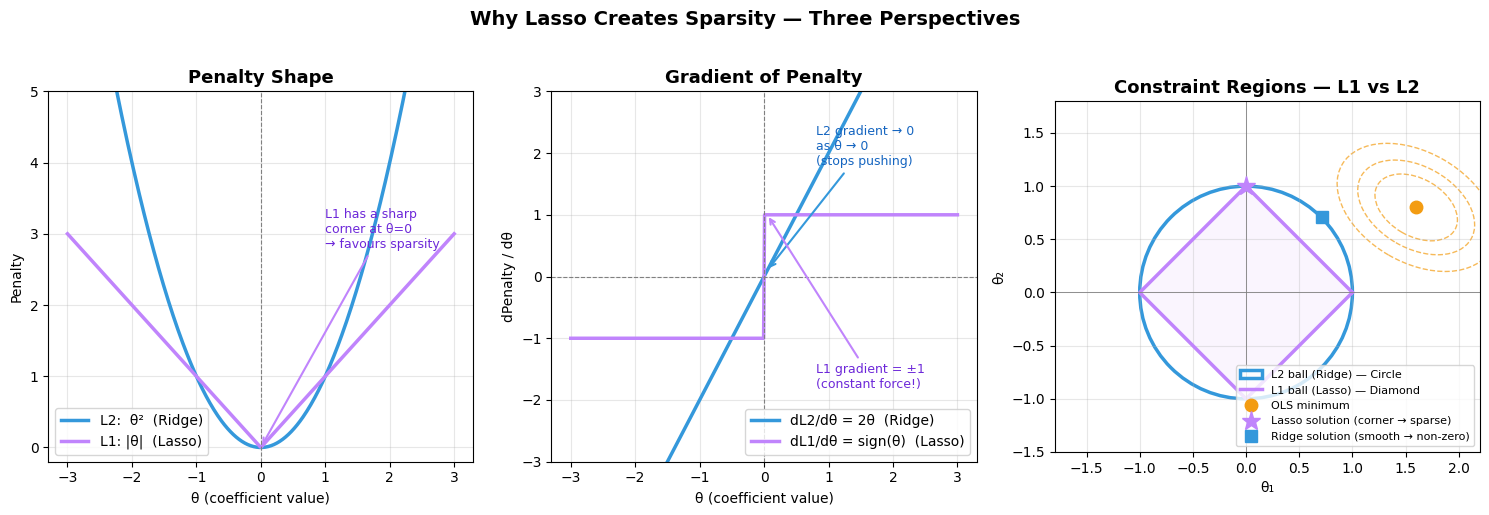

In [16]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

theta = np.linspace(-3, 3, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Plot 1: Penalty shape comparison ---
ax = axes[0]
ax.plot(theta, theta**2,    color='#3498db', linewidth=2.5, label='L2:  θ²  (Ridge)')
ax.plot(theta, np.abs(theta), color='#c084fc', linewidth=2.5, label='L1: |θ|  (Lasso)')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Penalty Shape', fontsize=13, fontweight='bold')
ax.set_xlabel('θ (coefficient value)')
ax.set_ylabel('Penalty')
ax.legend(fontsize=10)
ax.set_ylim(-0.2, 5)
ax.grid(True, alpha=0.3)
ax.annotate('L1 has a sharp\ncorner at θ=0\n→ favours sparsity',
            xy=(0, 0), xytext=(1.0, 2.8),
            fontsize=9, color='#6d28d9',
            arrowprops=dict(arrowstyle='->', color='#c084fc', lw=1.5))

# --- Plot 2: Gradient (derivative) comparison ---
ax = axes[1]
grad_l2 = 2 * theta
grad_l1 = np.sign(theta)
ax.plot(theta, grad_l2, color='#3498db', linewidth=2.5, label='dL2/dθ = 2θ  (Ridge)')
ax.plot(theta, grad_l1, color='#c084fc', linewidth=2.5, label='dL1/dθ = sign(θ)  (Lasso)')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Gradient of Penalty', fontsize=13, fontweight='bold')
ax.set_xlabel('θ (coefficient value)')
ax.set_ylabel('dPenalty / dθ')
ax.legend(fontsize=10)
ax.set_ylim(-3, 3)
ax.grid(True, alpha=0.3)
ax.annotate('L2 gradient → 0\nas θ → 0\n(stops pushing)',
            xy=(0.05, 0.1), xytext=(0.8, 1.8),
            fontsize=9, color='#1565c0',
            arrowprops=dict(arrowstyle='->', color='#3498db', lw=1.5))
ax.annotate('L1 gradient = ±1\n(constant force!)',
            xy=(0.05, 1.0), xytext=(0.8, -1.8),
            fontsize=9, color='#6d28d9',
            arrowprops=dict(arrowstyle='->', color='#c084fc', lw=1.5))

# --- Plot 3: Constraint regions (L1 diamond vs L2 circle) ---
ax = axes[2]
ax.set_aspect('equal')

# L2 circle
circle = plt.Circle((0, 0), 1.0, fill=False, color='#3498db',
                     linewidth=2.5, linestyle='-', label='L2 ball (Ridge) — Circle')
ax.add_patch(circle)

# L1 diamond
diamond_x = [1, 0, -1, 0, 1]
diamond_y = [0, 1,  0, -1, 0]
ax.plot(diamond_x, diamond_y, color='#c084fc', linewidth=2.5,
        linestyle='-', label='L1 ball (Lasso) — Diamond')
ax.fill(diamond_x, diamond_y, alpha=0.08, color='#c084fc')

# MSE ellipse contours (simulate)
ols_x, ols_y = 1.6, 0.8
for scale in [0.6, 0.85, 1.15]:
    ellipse = plt.matplotlib.patches.Ellipse(
        (ols_x, ols_y), width=scale*1.4, height=scale*0.9,
        angle=-30, fill=False, color='#f39c12', linewidth=1, linestyle='--', alpha=0.7)
    ax.add_patch(ellipse)

# Mark OLS optimum
ax.plot(ols_x, ols_y, 'o', color='#f39c12', markersize=9, label='OLS minimum', zorder=5)

# Mark intersection points
ax.plot(0, 1, '*', color='#c084fc', markersize=14, zorder=6, label='Lasso solution (corner → sparse)')
ax.plot(0.71, 0.71, 's', color='#3498db', markersize=9, zorder=6, label='Ridge solution (smooth → non-zero)')

ax.axhline(0, color='gray', linewidth=0.6)
ax.axvline(0, color='gray', linewidth=0.6)
ax.set_xlim(-1.8, 2.2)
ax.set_ylim(-1.5, 1.8)
ax.set_xlabel('θ₁')
ax.set_ylabel('θ₂')
ax.set_title('Constraint Regions — L1 vs L2', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)

plt.suptitle('Why Lasso Creates Sparsity — Three Perspectives',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<div style="background: #f5f0ff; border-left: 4px solid #c084fc; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 12px 0; font-size: 14px; color: #333;">
  <strong style="color: #6d28d9;">✅ Reading the three plots:</strong>
  <ul style="margin: 8px 0 0 0; padding-left: 18px; line-height: 2;">
    <li><strong>Left:</strong> L1 penalty has a sharp kink at θ=0 — L2 is smooth. The kink is the geometric origin of sparsity.</li>
    <li><strong>Middle:</strong> L2 gradient fades to zero as θ→0 (stops pushing). L1 gradient stays constant at ±1 (keeps pushing all the way to zero).</li>
    <li><strong>Right:</strong> The MSE ellipses touch the L1 diamond at a corner (θ₂=0 → sparse). They touch the L2 circle at a smooth point (both θ₁, θ₂ ≠ 0).</li>
  </ul>
</div>

<div style="background: linear-gradient(135deg, #1a0533 0%, #2d1b4e 100%); border-radius: 14px; padding: 36px 40px; margin-top: 32px;">
  <h2 style="color: #ffffff; font-size: 20px; font-weight: 700; margin: 0 0 20px 0;">📌 Summary &amp; Key Takeaways</h2>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px;">
    <div style="background: rgba(255,255,255,0.06); border: 1px solid rgba(192,132,252,0.3); border-radius: 10px; padding: 16px 18px;">
      <div style="color: #c084fc; font-weight: 700; font-size: 13px; margin-bottom: 6px;">✂️ Lasso = Feature Selector</div>
      <div style="color: #d4b8f0; font-size: 13px; line-height: 1.6;">L1 penalty drives weak coefficients to <strong style='color:#fff;'>exactly zero</strong>. Lasso is simultaneously a regularizer and an automatic feature selection method.</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid rgba(192,132,252,0.3); border-radius: 10px; padding: 16px 18px;">
      <div style="color: #c084fc; font-weight: 700; font-size: 13px; margin-bottom: 6px;">📦 Sparse Models</div>
      <div style="color: #d4b8f0; font-size: 13px; line-height: 1.6;">With 5000 features and only 50 informative, Lasso achieves R²≈0.997 while Linear Regression gets 0.18. Sparsity = interpretability + performance.</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid rgba(192,132,252,0.3); border-radius: 10px; padding: 16px 18px;">
      <div style="color: #c084fc; font-weight: 700; font-size: 13px; margin-bottom: 6px;">📉 Elimination Order</div>
      <div style="color: #d4b8f0; font-size: 13px; line-height: 1.6;">Weakest predictors are zeroed out first. The regularization path shows which features survive — a natural feature ranking tool.</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid rgba(192,132,252,0.3); border-radius: 10px; padding: 16px 18px;">
      <div style="color: #c084fc; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🔄 Lasso vs Ridge</div>
      <div style="color: #d4b8f0; font-size: 13px; line-height: 1.6;">Need sparse interpretable models with many irrelevant features? → <strong style='color:#fff;'>Lasso</strong>. Features are all useful and correlated? → <strong style='color:#fff;'>Ridge</strong>. Both? → <strong style='color:#fff;'>ElasticNet</strong>.</div>
    </div>
  </div>
  <div style="margin-top: 20px; padding-top: 16px; border-top: 1px solid rgba(192,132,252,0.2); color: #a78bca; font-size: 12px;">
    Next up → <strong style='color:#c084fc;'>ML 37: ElasticNet</strong> — combining L1 &amp; L2 penalties for the best of both worlds.
  </div>
</div>